In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!pip install google-api-python-client

In [ ]:
# ============================================================
# EXPANDED DATA COLLECTION
# More queries per niche + more niches + multi-key rotation
# Drop-in replacement for the original collection section
# ============================================================

import time
from googleapiclient.errors import HttpError
from googleapiclient.discovery import build
from google.colab import userdata

# ── API keys (add as many as you have) ──────────────────────
API_KEYS = [
    userdata.get('YOUTUBE_API_KEY_1'),
    userdata.get('YOUTUBE_API_KEY_2'),
    userdata.get('YOUTUBE_API_KEY_3')
    # remove if you only have one
    # userdata.get('YOUTUBE_API_KEY_3'), # uncomment when ready
]
# Filter out None values in case a secret isn't set
API_KEYS = [k for k in API_KEYS if k]
print(f"Loaded {len(API_KEYS)} API key(s)")

current_key_idx = 0

def get_client(idx):
    return build("youtube", "v3", developerKey=API_KEYS[idx])

youtube = get_client(0)

def rotate_key():
    """Switch to next available key. Raises if all keys exhausted."""
    global current_key_idx, youtube
    current_key_idx += 1
    if current_key_idx >= len(API_KEYS):
        raise RuntimeError("All API keys exhausted for today.")
    print(f"  ↳ Rotating to key {current_key_idx}")
    youtube = get_client(current_key_idx)


# ── Expanded niche keyword map ───────────────────────────────
# 5 queries per niche → 5× more coverage before deduplication
NICHE_KEYWORDS = {
    "Fitness": [
        "fitness youtube channel",
        "workout youtube channel",
        "gym training channel",
        "home workout channel",
        "bodybuilding youtube channel",
    ],
    "Tech": [
        "tech review channel",
        "smartphone review youtube",
        "gadget unboxing channel",
        "programming tutorial channel",
        "AI technology youtube channel",
    ],
    "Food": [
        "food youtube channel",
        "cooking youtube channel",
        "street food channel",
        "food review channel",
        "mukbang youtube channel",
    ],
    "Travel": [
        "travel vlog channel",
        "solo travel youtube",
        "budget travel channel",
        "luxury travel vlog",
        "travel documentary channel",
    ],
    "Beauty": [
        "beauty youtube channel",
        "makeup tutorial channel",
        "skincare youtube channel",
        "beauty review channel",
        "nail art youtube channel",
    ],
    "Finance": [
        "finance youtube channel",
        "personal finance channel",
        "stock market youtube",
        "investing youtube channel",
        "cryptocurrency channel",
    ],
    "Gaming": [
        "gaming youtube channel",
        "game review channel",
        "esports youtube channel",
        "indie game channel",
        "gaming walkthrough channel",
    ],
    "Education": [
        "education youtube channel",
        "online learning channel",
        "science explanation channel",
        "history youtube channel",
        "mathematics tutorial channel",
    ],
    "Health": [
        "health wellness youtube channel",
        "mental health youtube",
        "nutrition youtube channel",
        "yoga wellness channel",
        "medical education channel",
    ],
    "Fashion": [
        "fashion youtube channel",
        "style lookbook channel",
        "thrift fashion channel",
        "fashion haul youtube",
        "streetwear youtube channel",
    ],
    "Music": [
        "music youtube channel",
        "music production channel",
        "guitar tutorial channel",
        "music review youtube",
        "music theory channel",
    ],
    "Comedy": [
        "comedy youtube channel",
        "stand up comedy channel",
        "sketch comedy youtube",
        "prank youtube channel",
        "comedy skit channel",
    ],
    "Motivation": [
        "motivation youtube channel",
        "self improvement channel",
        "life advice youtube",
        "mindset motivation channel",
        "productivity youtube channel",
    ],
    "Cooking": [
        "cooking recipe youtube channel",
        "baking youtube channel",
        "vegan cooking channel",
        "quick recipe channel",
        "professional chef channel",
    ],
    # ── New niches ───────────────────────────────────────────
    "DIY": [
        "DIY youtube channel",
        "home improvement channel",
        "woodworking youtube channel",
        "crafts DIY channel",
        "upcycling youtube channel",
    ],
    "Parenting": [
        "parenting youtube channel",
        "mom vlog channel",
        "dad vlog youtube",
        "family youtube channel",
        "baby care youtube channel",
    ],
    "Sports": [
        "sports youtube channel",
        "cricket channel india",
        "football analysis channel",
        "basketball youtube channel",
        "sports highlights channel",
    ],
    "Photography": [
        "photography youtube channel",
        "camera review channel",
        "photo editing tutorial channel",
        "cinematography youtube",
        "street photography channel",
    ],
    "Business": [
        "entrepreneur youtube channel",
        "startup business channel",
        "marketing youtube channel",
        "business strategy channel",
        "ecommerce youtube channel",
    ],
    "Spirituality": [
        "meditation youtube channel",
        "yoga spirituality channel",
        "mindfulness youtube channel",
        "spiritual growth channel",
        "astrology youtube channel",
    ],
}

print(f"Niches: {len(NICHE_KEYWORDS)}")
print(f"Total queries: {sum(len(v) for v in NICHE_KEYWORDS.values())}")


# ── Safe wrappers with quota rotation ───────────────────────

def safe_search(niche, keyword, max_results=50):
    """Search with automatic key rotation on quota errors."""
    global youtube
    try:
        req = youtube.search().list(
            q=keyword,
            type="channel",
            part="snippet",
            maxResults=max_results,
        )
        resp = req.execute()
        ids = [item["snippet"]["channelId"] for item in resp["items"]]
        return ids
    except HttpError as e:
        if e.resp.status == 403 and "quotaExceeded" in str(e):
            rotate_key()
            return safe_search(niche, keyword, max_results)   # retry
        print(f"  HTTP error {e.resp.status} on '{keyword}': {e}")
        return []


def safe_channel_stats(channel_ids, niche):
    """Fetch channel stats with automatic key rotation."""
    global youtube
    try:
        req = youtube.channels().list(
            part="snippet,statistics,brandingSettings",
            id=",".join(channel_ids),
        )
        resp = req.execute()
        results = []
        for item in resp["items"]:
            stats   = item.get("statistics", {})
            snippet = item.get("snippet", {})
            results.append({
                "channel_id":   item["id"],
                "channel_name": snippet.get("title", ""),
                "niche":        niche,
                "country":      snippet.get("country", "Unknown"),
                "description":  snippet.get("description", "")[:200],
                "subscribers":  int(stats.get("subscriberCount", 0)),
                "total_views":  int(stats.get("viewCount", 0)),
                "total_videos": int(stats.get("videoCount", 0)),
                "published_at": snippet.get("publishedAt", ""),
            })
        return results
    except HttpError as e:
        if e.resp.status == 403 and "quotaExceeded" in str(e):
            rotate_key()
            return safe_channel_stats(channel_ids, niche)
        print(f"  HTTP error {e.resp.status} fetching stats: {e}")
        return []


# ── Main collection loop ─────────────────────────────────────

all_channels  = []
seen_ids      = set()        # global dedup across all niches
quota_tracker = 0            # rough unit tracker (search=100, stats=1)

for niche, keywords in NICHE_KEYWORDS.items():
    niche_new = 0
    print(f"\n{'─'*50}")
    print(f"Niche: {niche} ({len(keywords)} queries)")

    for keyword in keywords:
        ids = safe_search(niche, keyword, max_results=50)
        quota_tracker += 100

        # Deduplicate before hitting the stats endpoint
        new_ids = [cid for cid in ids if cid not in seen_ids]
        seen_ids.update(new_ids)

        if not new_ids:
            print(f"  '{keyword}' → 0 new (all duplicates)")
            continue

        stats = safe_channel_stats(new_ids, niche)
        quota_tracker += len(new_ids)       # channels.list is 1 unit each
        all_channels.extend(stats)
        niche_new += len(stats)
        print(f"  '{keyword}' → {len(new_ids)} new channels")

        # Save after every query so you never lose progress
        pd.DataFrame(all_channels).to_csv("influencers_raw_progress.csv", index=False)
        time.sleep(1.5)    # stay well within rate limits

    print(f"  {niche} total new: {niche_new}")
    print(f"  Running total: {len(all_channels)} | ~Quota used: {quota_tracker} units")

df = pd.DataFrame(all_channels)
df.to_csv("influencers_youtube_raw.csv", index=False)
print(f"\nCollection done. {len(df)} rows saved to influencers_youtube_raw.csv")
print(f"Approximate quota used: {quota_tracker} units")
df.info()

In [ ]:
df["avg_views_per_video"] = df["total_views"] / df["total_videos"].replace(0, 1)
# Raw engagement rate
df["engagement_rate_raw"] = (
    df["avg_views_per_video"] / df["subscribers"].replace(0, 1)
) * 100
# Log transform — compresses outliers WITHOUT flattening everyone
# This preserves differentiation between influencers
df["engagement_rate"] = np.log1p(df["engagement_rate_raw"]).round(4)
df[["channel_name", "niche", "subscribers",
    "avg_views_per_video", "engagement_rate_raw", "engagement_rate"]].head(10)


,channel_name,niche,subscribers,avg_views_per_video,engagement_rate_raw,engagement_rate
0,Family Fitness,Fitness,15700000,4.695630e+06,29.908474,3.4310
1,Health & Fitness guide,Fitness,0,5.000000e-01,50.000000,3.9318
2,Fitness Withshuva🫡,Fitness,51,2.403333e+02,471.241830,6.1575
3,EFFECTIVE WORKOUT,Fitness,165000,1.884609e+04,11.421875,2.5195
4,Kinetic Mindset,Fitness,0,7.500000e+00,750.000000,6.6214
5,Positive Fit With Ruchira,Fitness,79700,3.740640e+04,46.934008,3.8698
6,Guru Mann Fitness,Fitness,2400000,3.714492e+05,15.477049,2.8020
7,Kush fitness,Fitness,1190000,1.687310e+05,14.179079,2.7199
8,Fitness Boxing - Topic,Fitness,549,0.000000e+00,0.000000,0.0000
9,Malik Fitness,Fitness,3870000,6.108826e+05,15.785081,2.8205


In [ ]:
print("Unique engagement_rate values:", df["engagement_rate"].nunique())
print("Max:", df["engagement_rate"].max())
print("Min:", df["engagement_rate"].min())


Unique engagement_rate values: 4458
Max: 11.9661
Min: 0.0


In [ ]:
df.to_csv("influencers_youtube.csv", index=False)
print("Saved!")

Saved!


In [ ]:
df.head()

,channel_id,channel_name,niche,country,description,subscribers,total_views,total_videos,published_at,avg_views_per_video,engagement_rate_raw,engagement_rate
0,UCvVEcGPPEkn3zSdc-rniGMg,Family Fitness,Fitness,IN,For Promotions & Collaborations: \nEmail: tea...,15700000,12908288083,2749,2017-01-18T04:40:33Z,4.695630e+06,29.908474,3.4310
1,UCl1hQQL9Yg6-sIdfEnBYzyA,Health & Fitness guide,Fitness,Unknown,"This channel is all about real health, real fi...",0,1,2,2026-05-11T12:14:31.405734Z,5.000000e-01,50.000000,3.9318
2,UC4F0437BVkU4qHFCXLUv6yw,Fitness Withshuva🫡,Fitness,IN,Hello guys 🫡\nWelcome to my channel 🫡\nHere I ...,51,721,3,2026-05-12T14:08:27.118198Z,2.403333e+02,471.241830,6.1575
3,UC5FNiPVkYzw5040Fx3s576A,EFFECTIVE WORKOUT,Fitness,US,"◼ Welcome to EFFECTIVE WORKOUT Channel!\nHere,...",165000,16603409,881,2020-10-22T06:12:49.899641Z,1.884609e+04,11.421875,2.5195
4,UC9J09h3s5gERpgcktTIADQw,Kinetic Mindset,Fitness,Unknown,\n,0,15,2,2026-05-12T05:19:30.338839Z,7.500000e+00,750.000000,6.6214


In [ ]:
df_clean = df[
    (df["subscribers"] >= 5000) &      # minimum 10k subscribers
    (df["total_views"] >= 25000) &      # minimum 50k total views
    (df["total_videos"] >= 5) &         # at least 5 videos
    (df["engagement_rate"] <= 100) &    # remove broken engagement rates
    (df["engagement_rate"] > 0)         # remove zero engagement
]

print("Before filter:", len(df))
print("After filter:", len(df_clean))
df_clean.head()

Before filter: 4801
After filter: 2836


,channel_id,channel_name,niche,country,description,subscribers,total_views,total_videos,published_at,avg_views_per_video,engagement_rate_raw,engagement_rate
0,UCvVEcGPPEkn3zSdc-rniGMg,Family Fitness,Fitness,IN,For Promotions & Collaborations: \nEmail: tea...,15700000,12908288083,2749,2017-01-18T04:40:33Z,4.695630e+06,29.908474,3.4310
3,UC5FNiPVkYzw5040Fx3s576A,EFFECTIVE WORKOUT,Fitness,US,"◼ Welcome to EFFECTIVE WORKOUT Channel!\nHere,...",165000,16603409,881,2020-10-22T06:12:49.899641Z,1.884609e+04,11.421875,2.5195
5,UCtno9MsKRuSkS80jhQ8V-bg,Positive Fit With Ruchira,Fitness,Unknown,😊✨ Welcome to Positive Vibes Hub! ✨😊\nI’m Ruch...,79700,13129648,351,2024-08-29T06:45:30.47337Z,3.740640e+04,46.934008,3.8698
6,UCGMOauU8dOd4mv2bT3Tx57w,Guru Mann Fitness,Fitness,US,"Guru Mann, world's first fitness professional ...",2400000,196496608,529,2015-12-05T07:29:20Z,3.714492e+05,15.477049,2.8020
7,UChy4qc0Gt26NsMfldeQ2DMQ,Kush fitness,Fitness,IN,राम राम जी\nWelcome to Kush fitness\nइस चैनल प...,1190000,143252650,849,2017-11-06T09:47:50Z,1.687310e+05,14.179079,2.7199


In [ ]:
print(df_clean.shape)
print(df_clean.dtypes)
print(df_clean.isnull().sum())

(2836, 12)
channel_id              object
channel_name            object
niche                   object
country                 object
description             object
subscribers              int64
total_views              int64
total_videos             int64
published_at            object
avg_views_per_video    float64
engagement_rate_raw    float64
engagement_rate        float64
dtype: object
channel_id             0
channel_name           0
niche                  0
country                0
description            0
subscribers            0
total_views            0
total_videos           0
published_at           0
avg_views_per_video    0
engagement_rate_raw    0
engagement_rate        0
dtype: int64


In [ ]:
print("Duplicate channels:", df_clean.duplicated(subset="channel_id").sum())

Duplicate channels: 0


In [ ]:
df_clean = df_clean.drop_duplicates(subset="channel_id", keep="first")
print("After removing duplicates:", len(df_clean))

After removing duplicates: 2836


In [ ]:
# Fix 2 — handle mixed date formats
df_clean["published_at"] = pd.to_datetime(df_clean["published_at"], format="ISO8601")

In [ ]:
# Fix 3 — log transform already handled outliers
print("Engagement rate range:", df_clean["engagement_rate"].min(),
      "to", df_clean["engagement_rate"].max())
print("Unique values:", df_clean["engagement_rate"].nunique())

Engagement rate range: 0.2949 to 9.8679
Unique values: 2737


Raw data:  "channel created on 2018-01-01" and "posted 200 videos"
           ↓  feature engineering
New features: "6 years old" and "posts 33 videos per year"

Example:
Channel created:  2018-01-01
Today:            2026-04-07
Difference:       8.26 years

Total videos:      400
Account age:       8 years
Posting frequency: 400 / 8 = 50 videos per year = ~1 per week

In [ ]:
#Feature Engineering

from datetime import datetime

# Account age in years
df_clean["account_age_years"] = (
    pd.Timestamp.now(tz="UTC") - df_clean["published_at"]
).dt.days / 365

df_clean["posting_frequency"] = (
    df_clean["total_videos"] / df_clean["account_age_years"].replace(0, 1)
).round(2)


In [ ]:
# Influencer tier
def assign_tier(subs):
    if subs >= 1_000_000:
        return "Mega"
    elif subs >= 100_000:
        return "Macro"
    elif subs >= 10_000:
        return "Micro"
    else:
        return "Nano"

df_clean["influencer_tier"] = df_clean["subscribers"].apply(assign_tier)

print(df_clean["influencer_tier"].value_counts())
print("\nFinal dataset shape:", df_clean.shape)
df_clean.head()

influencer_tier
Macro    1032
Micro     848
Mega      733
Nano      223
Name: count, dtype: int64

Final dataset shape: (2836, 15)


,channel_id,channel_name,niche,country,description,subscribers,total_views,total_videos,published_at,avg_views_per_video,engagement_rate_raw,engagement_rate,account_age_years,posting_frequency,influencer_tier
0,UCvVEcGPPEkn3zSdc-rniGMg,Family Fitness,Fitness,IN,For Promotions & Collaborations: \nEmail: tea...,15700000,12908288083,2749,2017-01-18 04:40:33+00:00,4.695630e+06,29.908474,3.4310,9.323288,294.85,Mega
3,UC5FNiPVkYzw5040Fx3s576A,EFFECTIVE WORKOUT,Fitness,US,"◼ Welcome to EFFECTIVE WORKOUT Channel!\nHere,...",165000,16603409,881,2020-10-22 06:12:49.899641+00:00,1.884609e+04,11.421875,2.5195,5.561644,158.41,Macro
5,UCtno9MsKRuSkS80jhQ8V-bg,Positive Fit With Ruchira,Fitness,Unknown,😊✨ Welcome to Positive Vibes Hub! ✨😊\nI’m Ruch...,79700,13129648,351,2024-08-29 06:45:30.473370+00:00,3.740640e+04,46.934008,3.8698,1.706849,205.64,Micro
6,UCGMOauU8dOd4mv2bT3Tx57w,Guru Mann Fitness,Fitness,US,"Guru Mann, world's first fitness professional ...",2400000,196496608,529,2015-12-05 07:29:20+00:00,3.714492e+05,15.477049,2.8020,10.446575,50.64,Mega
7,UChy4qc0Gt26NsMfldeQ2DMQ,Kush fitness,Fitness,IN,राम राम जी\nWelcome to Kush fitness\nइस चैनल प...,1190000,143252650,849,2017-11-06 09:47:50+00:00,1.687310e+05,14.179079,2.7199,8.523288,99.61,Mega


In [ ]:
df_clean.to_csv("influencers_clean.csv", index=False)
print("Dataset saved!")

Dataset saved!


In [ ]:
from sklearn.preprocessing import MinMaxScaler
df_scored = df_clean.copy()
df_scored["log_subscribers"]        = np.log1p(df_scored["subscribers"])
df_scored["log_avg_views"]          = np.log1p(df_scored["avg_views_per_video"])
df_scored["log_posting_frequency"]  = np.log1p(df_scored["posting_frequency"])
score_features = [
    "log_subscribers",
    "log_avg_views",
    "engagement_rate",       # already log1p from preprocessing
    "log_posting_frequency"
]
df_scored["influencer_score"] = 0.0
scaler = MinMaxScaler()

for tier in ["Nano", "Micro", "Macro", "Mega"]:

    mask = df_scored["influencer_tier"] == tier

    # Skip if tier has no influencers
    if mask.sum() == 0:
        print(f"⚠️  No influencers for tier: {tier}, skipping...")
        continue

    tier_df = df_scored[mask].copy()

    # Scale features within this tier only (0 to 1)
    tier_scaled = pd.DataFrame(
        scaler.fit_transform(tier_df[score_features]),
        columns=score_features,
        index=tier_df.index
    )
    score = (
        0.35 * tier_scaled["engagement_rate"]       +
        0.30 * tier_scaled["log_avg_views"]         +
        0.20 * tier_scaled["log_subscribers"]       +
        0.15 * tier_scaled["log_posting_frequency"]
    ).round(4)

    df_scored.loc[mask, "influencer_score"] = score

# Sort within each tier by score
df_scored = df_scored.sort_values(
    ["influencer_tier", "influencer_score"],
    ascending=[True, False]
).reset_index(drop=True)
print("=" * 65)
print("TOP 3 INFLUENCERS PER TIER")
print("=" * 65)

for tier in ["Nano", "Micro", "Macro", "Mega"]:
    tier_data = df_scored[df_scored["influencer_tier"] == tier]

    if tier_data.empty:
        print(f"\n⚠️  {tier}: No data")
        continue

    print(f"\n🏷️  {tier} ({len(tier_data)} total)")
    print("-" * 65)
    print(tier_data.head(3)[
        ["channel_name", "niche", "subscribers",
         "engagement_rate", "influencer_score"]
    ].to_string())

print("\n" + "=" * 65)
print(f"✅ Scoring done! Total: {len(df_scored)} influencers")

TOP 3 INFLUENCERS PER TIER

🏷️  Nano (223 total)
-----------------------------------------------------------------
             channel_name      niche  subscribers  engagement_rate  influencer_score
2613    Science Explained  Education         9080           8.1754            0.8003
2614   Samrasfoodchannel        Food         9350           6.2896            0.7481
2615  Dan Cummins - Topic     Comedy         9350           6.7782            0.7405

🏷️  Micro (848 total)
-----------------------------------------------------------------
                   channel_name      niche  subscribers  engagement_rate  influencer_score
1765  Wyeth Nutrition Indonesia     Health        32300           9.8679            0.8028
1766         I Love Basketball      Sports        58000           7.8475            0.7865
1767           Child Care Blog   Parenting        78900           6.9335            0.7264

🏷️  Macro (1032 total)
-----------------------------------------------------------------
  

In [ ]:
# ============================================================
# STEP 3 — CLUSTERING WITHIN EACH TIER
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,
                              davies_bouldin_score,
                              calinski_harabasz_score)
from collections import Counter

# ---------------------------------------------------------
# Same features used for scoring
# We cluster on same features so clusters reflect
# the same dimensions we scored on
# ---------------------------------------------------------
cluster_features = [
    "log_subscribers",
    "log_avg_views",
    "engagement_rate",
    "log_posting_frequency"
]

cluster_scaler          = MinMaxScaler()
df_scored["cluster"]    = -1   # default -1 means unassigned

for tier in ["Micro", "Macro", "Mega"]:
    mask    = df_scored["influencer_tier"] == tier
    tier_df = df_scored[mask].copy()

    print(f"\n{'='*55}")
    print(f"🏷️  Finding best K for {tier} ({len(tier_df)} influencers)")
    print(f"{'='*55}")

    # Scale features within this tier only
    X = cluster_scaler.fit_transform(tier_df[cluster_features])

    # -------------------------------------------------
    # VOTING — 3 methods to find best K
    # Range k=2 to k=6
    # Small range because we are already within
    # a tier — too many sub-groups makes no sense
    # -------------------------------------------------
    k_range           = range(2, 7)
    silhouette_scores = []
    db_scores         = []
    ch_scores         = []

    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        silhouette_scores.append(silhouette_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))

    # Each method votes for best k
    vote_sil = k_range[silhouette_scores.index(max(silhouette_scores))]
    vote_db  = k_range[db_scores.index(min(db_scores))]
    vote_ch  = k_range[ch_scores.index(max(ch_scores))]

    print(f"  Silhouette        → best k = {vote_sil}")
    print(f"  Davies-Bouldin    → best k = {vote_db}")
    print(f"  Calinski-Harabasz → best k = {vote_ch}")

    votes  = [vote_sil, vote_db, vote_ch]
    best_k = Counter(votes).most_common(1)[0][0]
    print(f"  🏆 Final best k   = {best_k}")

    # Apply KMeans with best k
    km     = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    df_scored.loc[mask, "cluster"] = labels

    # -------------------------------------------------
    # Show cluster profiles so we can label them
    # meaningfully in next step
    # -------------------------------------------------
    temp            = tier_df.copy()
    temp["cluster"] = labels

    print(f"\n  📊 Cluster profiles for {tier}:")
    profile = temp.groupby("cluster")[[
        "subscribers",
        "engagement_rate",
        "avg_views_per_video",
        "posting_frequency",
        "influencer_score"
    ]].mean().round(2)
    print(profile.to_string())

print("\n" + "="*55)
print("✅ Clustering done!")
print("\nCluster distribution:")
print(df_scored.groupby(["influencer_tier", "cluster"]).size())


🏷️  Finding best K for Micro (848 influencers)
  Silhouette        → best k = 2
  Davies-Bouldin    → best k = 2
  Calinski-Harabasz → best k = 2
  🏆 Final best k   = 2

  📊 Cluster profiles for Micro:
         subscribers  engagement_rate  avg_views_per_video  posting_frequency  influencer_score
cluster                                                                                        
0           60855.80             3.71             72777.64             153.27              0.48
1           18475.75             3.97             29820.72             129.68              0.36

🏷️  Finding best K for Macro (1032 influencers)
  Silhouette        → best k = 2
  Davies-Bouldin    → best k = 6
  Calinski-Harabasz → best k = 2
  🏆 Final best k   = 2

  📊 Cluster profiles for Macro:
         subscribers  engagement_rate  avg_views_per_video  posting_frequency  influencer_score
cluster                                                                                        
0          194909

In [ ]:
#label cluster meaningfully
# MICRO:
# cluster 0 → higher subs + views        → "Rising Stars"
# cluster 1 → smaller + lower engagement → "Niche Creators"
#
# MACRO:
# cluster 0 → high reach + decent eng    → "High Reach"
# cluster 1 → low engagement + high post → "Frequent Posters"
# cluster 2 → best engagement            → "High Engagement"
#
# MEGA:
# cluster 0 → massive reach + decent eng → "Mass Reach"
# cluster 1 → lowest overall performers  → "Low Performers"
# cluster 2 → best engagement in Mega    → "Mega Engaged"
cluster_label_map = {
    "Micro": {
        0: "Rising Stars",       # higher subs, decent engagement
        1: "Niche Creators"      # smaller, loyal niche audience
    },
    "Macro": {
        0: "High Reach",         # large subs, decent engagement
        1: "Frequent Posters",   # posts a lot but low engagement
        2: "High Engagement"     # best engagement rate in Macro
    },
    "Mega": {
        0: "Mass Reach",         # massive subs + views
        1: "Low Performers",     # lowest engagement + views
        2: "Mega Engaged"        # best engagement in Mega
    }
}

# Apply labels
df_scored["cluster_label"] = df_scored.apply(
    lambda row: cluster_label_map
                .get(row["influencer_tier"], {})
                .get(row["cluster"], "Unknown"),
    axis=1
)

# ---------------------------------------------------------
# Verify — show distribution and sample per cluster
# ---------------------------------------------------------
print("=" * 65)
print("CLUSTER LABEL DISTRIBUTION")
print("=" * 65)
print(df_scored.groupby(
    ["influencer_tier", "cluster_label"]
).size().to_string())

print("\n" + "=" * 65)
print("TOP 2 PER CLUSTER")
print("=" * 65)

for tier in ["Micro", "Macro", "Mega"]:
    tier_data = df_scored[df_scored["influencer_tier"] == tier]
    labels    = tier_data["cluster_label"].unique()

    print(f"\n🏷️  {tier}")
    print("-" * 65)

    for label in sorted(labels):
        cluster_data = tier_data[tier_data["cluster_label"] == label]
        print(f"\n  📌 {label} ({len(cluster_data)} influencers)")
        print(cluster_data.nlargest(2, "influencer_score")[
            ["channel_name", "niche", "subscribers",
             "engagement_rate", "influencer_score"]
        ].to_string())

print("\n" + "=" * 65)
print("✅ Cluster labeling done!")
print(f"Final shape: {df_scored.shape}")

CLUSTER LABEL DISTRIBUTION
influencer_tier  cluster_label   
Macro            Frequent Posters    489
                 High Reach          543
Mega             Low Performers      337
                 Mass Reach          220
                 Mega Engaged        176
Micro            Niche Creators      400
                 Rising Stars        448
Nano             Unknown             223

TOP 2 PER CLUSTER

🏷️  Micro
-----------------------------------------------------------------

  📌 Niche Creators (400 influencers)
                             channel_name   niche  subscribers  engagement_rate  influencer_score
1773  Vicky & Piya ♡ Luxury Travel Couple  Travel        16600           9.4480            0.6832
1778                  Dot & Key Skincare   Beauty        27400           7.8182            0.6686

  📌 Rising Stars (448 influencers)
                   channel_name   niche  subscribers  engagement_rate  influencer_score
1765  Wyeth Nutrition Indonesia  Health        32300       

In [ ]:
#brand selection function
def get_affordable_tiers(budget):
    if budget is None:
        return ["Micro", "Macro", "Mega"]   # no filter
    elif budget < 500:
        return ["Micro"]
    elif budget < 5000:
        return ["Micro", "Macro"]
    else:
        return ["Micro", "Macro", "Mega"]

GOAL_CLUSTER_MAP = {
    "engagement": ["High Engagement", "Rising Stars",
                   "Mega Engaged"],
    "reach"     : ["High Reach", "Mass Reach"],
    "niche"     : ["Niche Creators"],
    "consistent": ["Frequent Posters"]
}

def select_influencers(
    df,
    niche          = None,    # e.g. "Gaming", "Fitness"
    country        = None,    # e.g. "IN", "US"
    budget         = None,    # brand budget in USD per video
    goal           = None,    # "engagement","reach","niche","consistent"
    min_engagement = 0.0,     # minimum engagement rate
    top_n          = 15       # how many results to return
):
    """
    Returns top N influencers matching brand criteria.
    Ranked by influencer_score within each tier.

    Parameters:
    -----------
    niche          : content niche to filter
    country        : country code to filter
    budget         : brand budget in USD — auto maps to tier
    goal           : campaign goal — filters cluster type
    min_engagement : minimum engagement rate threshold
    top_n          : number of results to return
    """
    result = df.copy()

    #step 1: filter by niche
    if niche:
        result = result[result["niche"].str.lower() == niche.lower()]
        print(f"  After niche filter     : {len(result)} influencers")

    #step 2: filter by country
    if country:
        result = result[result["country"].str.upper() == country.upper()]
        print(f"  After country filter   : {len(result)} influencers")

    #step 3: filter by budget -> tier
    affordable_tiers = get_affordable_tiers(budget)
    result = result[result["influencer_tier"].isin(affordable_tiers)]
    print(f"  After budget filter    : {len(result)} influencers")
    print(f"  Affordable tiers       : {affordable_tiers}")

    #step 4: filter by campaign goal -> cluster
    if goal and goal.lower() in GOAL_CLUSTER_MAP:
        preferred_clusters = GOAL_CLUSTER_MAP[goal.lower()]
        result = result[result["cluster_label"].isin(preferred_clusters)]
        print(f"  After goal filter      : {len(result)} influencers")
        print(f"  Preferred clusters     : {preferred_clusters}")

    #step 5: filter by minimum engagement
    if min_engagement > 0:
        result = result[result["engagement_rate"] >= min_engagement]
        print(f"  After engagement filter: {len(result)} influencers")

    #step 6: check if any reults remain
    if result.empty:
        print("\n⚠️  No influencers found matching criteria.")
        print("💡 Try: relaxing budget, removing country filter,")
        print("        or changing goal.")
        return pd.DataFrame()

    #step 7: rank by influencer_score and return top N
    output_cols = [
        "channel_name",
        "niche",
        "country",
        "influencer_tier",
        "cluster_label",
        "subscribers",
        "engagement_rate",
        "avg_views_per_video",
        "posting_frequency",
        "influencer_score"
    ]

    top = result.nlargest(top_n, "influencer_score")[output_cols]
    top = top.reset_index(drop=True)
    top.index += 1    # rank starts from 1

    return top


print("✅ select_influencers() function ready!")


✅ select_influencers() function ready!


In [ ]:
#USE CASE 3
print("\n" + "=" * 65)
print("USE CASE 3: Big Tech Brand | Budget $50000 | Goal: Reach")
print("=" * 65)
r3 = select_influencers(
    df_scored,
    niche  = "Tech",
    budget = 50000,
    goal   = "reach",
    top_n  = 5
)
print(r3.to_string() if not r3.empty else "No results")


USE CASE 3: Big Tech Brand | Budget $50000 | Goal: Reach
  After niche filter     : 111 influencers
  After budget filter    : 102 influencers
  Affordable tiers       : ['Micro', 'Macro', 'Mega']
  After goal filter      : 18 influencers
  Preferred clusters     : ['High Reach', 'Mass Reach']
           channel_name niche  country influencer_tier cluster_label  subscribers  engagement_rate  avg_views_per_video  posting_frequency  influencer_score
1           Byte Review  Tech       GB           Macro    High Reach       247000           4.4969        219176.580902              35.09            0.5169
2  Consumer Tech Review  Tech       US           Macro    High Reach       232000           4.0128        125983.117229              67.02            0.4812
3        Greek Unboxing  Tech       GR           Macro    High Reach       258000           3.6319         94907.278856             120.93            0.4731
4             AI Upload  Tech       US           Macro    High Reach       1

In [ ]:
# USE CASE 4
# Fitness brand
# No budget constraint
# Wants high engagement minimum 4.0
# ---------------------------------------------------------
print("\n" + "=" * 65)
print("USE CASE 4: Fitness Brand | No Budget Limit | Min Engagement 4.0")
print("=" * 65)
r4 = select_influencers(
    df_scored,
    niche          = "Fitness",
    min_engagement = 4.0,
    top_n          = 5
)
print(r4.to_string() if not r4.empty else "No results")


USE CASE 4: Fitness Brand | No Budget Limit | Min Engagement 4.0
  After niche filter     : 103 influencers
  After budget filter    : 95 influencers
  Affordable tiers       : ['Micro', 'Macro', 'Mega']
  After engagement filter: 31 influencers
                              channel_name    niche country influencer_tier     cluster_label  subscribers  engagement_rate  avg_views_per_video  posting_frequency  influencer_score
1                               Miss Linky  Fitness      ZA           Macro  Frequent Posters       553000           5.7302         1.697818e+06              21.02            0.7054
2                             BODYBUILDING  Fitness      US           Macro  Frequent Posters       956000           4.7192         1.061891e+06              39.20            0.6983
3  Fanzi Bodybuilding & Fitness Motivation  Fitness      FR           Micro      Rising Stars        65700           7.2386         9.139824e+05               1.04            0.6655
4           Calisthenics 

In [ ]:
# USE CASE 5
# Any brand — overall top 10 across all niches
# Budget = $1000
# Goal   = engagement
# ---------------------------------------------------------
print("\n" + "=" * 65)
print("USE CASE 5: Any Brand | Budget $1000 | Top 10 Overall")
print("=" * 65)
r5 = select_influencers(
    df_scored,
    budget = 1000,
    goal   = "engagement",
    top_n  = 10
)
print(r5.to_string() if not r5.empty else "No results")


USE CASE 5: Any Brand | Budget $1000 | Top 10 Overall
  After budget filter    : 1880 influencers
  Affordable tiers       : ['Micro', 'Macro']
  After goal filter      : 448 influencers
  Preferred clusters     : ['High Engagement', 'Rising Stars', 'Mega Engaged']
                  channel_name       niche  country influencer_tier cluster_label  subscribers  engagement_rate  avg_views_per_video  posting_frequency  influencer_score
1    Wyeth Nutrition Indonesia      Health       ID           Micro  Rising Stars        32300           9.8679         6.233697e+06              23.87            0.8028
2           I Love Basketball       Sports  Unknown           Micro  Rising Stars        58000           7.8475         1.483802e+06             341.04            0.7865
3             Child Care Blog    Parenting       IN           Micro  Rising Stars        78900           6.9335         8.087749e+05              49.91            0.7264
4          Céline Dion - Topic       Music  Unknown  

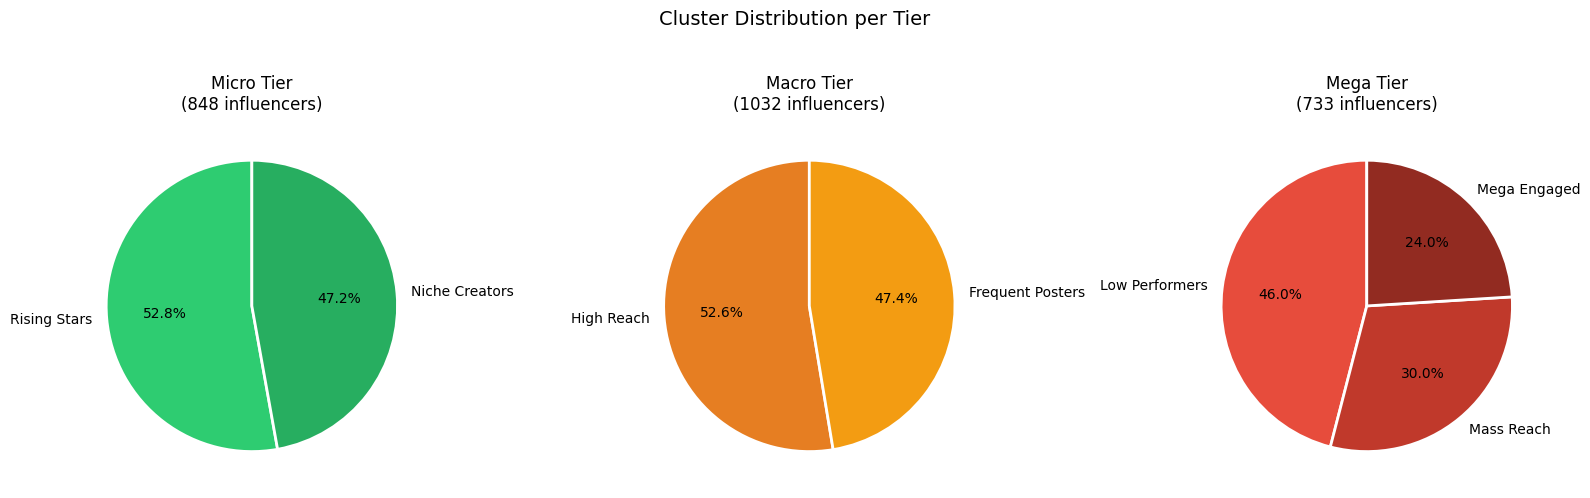

In [ ]:
# PLOT 3 — Cluster Distribution per Tier
# What it shows: how influencers are spread
# across clusters within each tier
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tiers  = ["Micro", "Macro", "Mega"]
colors = [
    ["#2ecc71", "#27ae60"],
    ["#e67e22", "#f39c12", "#d35400"],
    ["#e74c3c", "#c0392b", "#922b21"]
]

for i, tier in enumerate(tiers):
    tier_data = df_scored[df_scored["influencer_tier"] == tier]
    counts    = tier_data["cluster_label"].value_counts()

    axes[i].pie(
        counts.values,
        labels=counts.index,
        colors=colors[i],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    axes[i].set_title(f"{tier} Tier\n({len(tier_data)} influencers)",
                      fontsize=12, pad=10)

plt.suptitle("Cluster Distribution per Tier", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

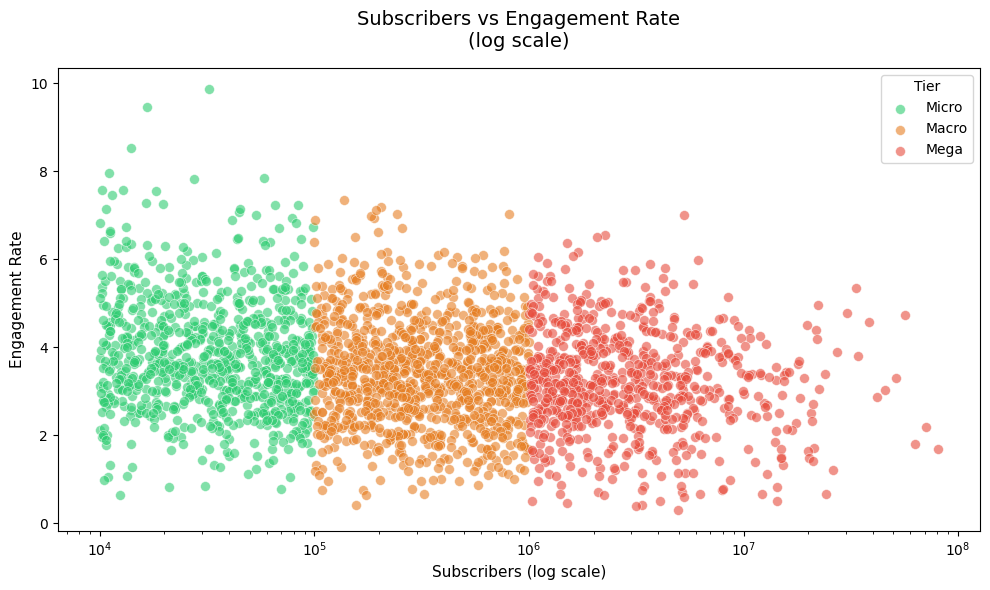

In [ ]:
# PLOT 4 — Subscribers vs Engagement Rate (all influencers)
# What it shows: the classic trade-off —
# bigger channels = lower engagement rate
# Color = tier, helps see the pattern clearly
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

tier_colors = {
    "Micro": "#2ecc71",
    "Macro": "#e67e22",
    "Mega" : "#e74c3c"
}

for tier, color in tier_colors.items():
    subset = df_scored[df_scored["influencer_tier"] == tier]
    ax.scatter(
        subset["subscribers"],
        subset["engagement_rate"],
        c=color,
        label=tier,
        alpha=0.6,
        s=50,
        edgecolors="white",
        linewidth=0.5
    )

ax.set_xscale("log")
ax.set_title("Subscribers vs Engagement Rate\n(log scale)",
             fontsize=14, pad=15)
ax.set_xlabel("Subscribers (log scale)", fontsize=11)
ax.set_ylabel("Engagement Rate", fontsize=11)
ax.legend(title="Tier", fontsize=10)
plt.tight_layout()
plt.show()

KeyError: 'Nano'

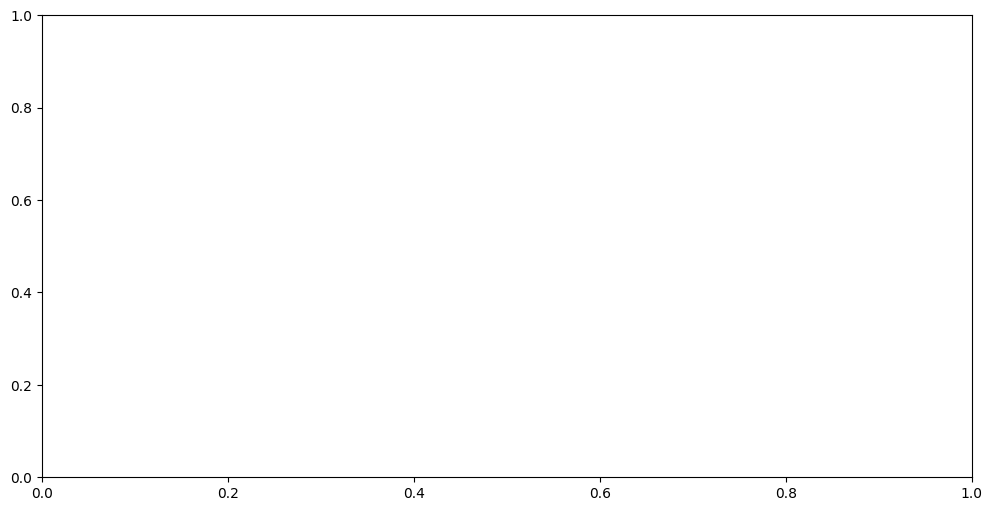

In [ ]:
# PLOT 5 — Top 10 Influencers Overall by Score
# What it shows: best influencers across all tiers
# based on influencer_score
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

top10_overall = df_scored.nlargest(10, "influencer_score")

bars = ax.barh(
    top10_overall["channel_name"],
    top10_overall["influencer_score"],
    color=[tier_colors[t] for t in top10_overall["influencer_tier"]],
    edgecolor="white",
    height=0.6
)

# Add tier label inside bar
for bar, tier in zip(bars, top10_overall["influencer_tier"]):
    ax.text(
        bar.get_width() - 0.02,
        bar.get_y() + bar.get_height() / 2,
        tier,
        va="center", ha="right",
        color="white", fontsize=9, fontweight="bold"
    )

ax.set_title("Top 10 Influencers by Score (All Tiers)",
             fontsize=14, pad=15)
ax.set_xlabel("Influencer Score", fontsize=11)
ax.invert_yaxis()

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Micro"),
    Patch(facecolor="#e67e22", label="Macro"),
    Patch(facecolor="#e74c3c", label="Mega")
]
ax.legend(handles=legend_elements, title="Tier", loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STAGE 5A — NLP ON CHANNEL DESCRIPTIONS
# Input : df_scored  (has 'description', 'niche', 'cluster_label', 'influencer_score')
# Output: df_nlp     (adds topic_label, sentiment_score, top_keywords columns)
# ============================================================

# pip install nltk textblob scikit-learn wordcloud matplotlib
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)

from nltk.corpus            import stopwords
from textblob               import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition  import LatentDirichletAllocation
from wordcloud              import WordCloud
from collections            import defaultdict

STOP = set(stopwords.words("english"))

# ─────────────────────────────────────────────
# 1. Text cleaning
# ─────────────────────────────────────────────
def clean_text(text):
    """Lowercase, strip URLs/special chars, remove stopwords."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)               # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP and len(t) > 2]
    return " ".join(tokens)

df_nlp = df_scored.copy()
df_nlp["clean_desc"] = df_nlp["description"].fillna("").apply(clean_text)

print("Sample cleaned description:")
print(df_nlp["clean_desc"].iloc[0])

# ─────────────────────────────────────────────
# 2. Sentiment analysis with TextBlob
#    polarity: -1 (negative) to +1 (positive)
#    subjectivity: 0 (objective) to 1 (subjective)
# ─────────────────────────────────────────────
def get_sentiment(text):
    blob = TextBlob(text)
    return pd.Series({
        "sentiment_polarity":    round(blob.sentiment.polarity,    4),
        "sentiment_subjectivity": round(blob.sentiment.subjectivity, 4)
    })

sentiment_df = df_nlp["description"].fillna("").apply(get_sentiment)
df_nlp = pd.concat([df_nlp, sentiment_df], axis=1)

print("\nSentiment distribution:")
print(df_nlp["sentiment_polarity"].describe().round(3))

# ─────────────────────────────────────────────
# 3. TF-IDF → top keywords per channel
# ─────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features = 200,
    ngram_range  = (1, 2),   # unigrams + bigrams
    min_df       = 2          # word must appear in at least 2 docs
)

tfidf_matrix = tfidf.fit_transform(df_nlp["clean_desc"])
feature_names = np.array(tfidf.get_feature_names_out())

# Top 5 keywords per channel
def top_keywords(row_idx, n=5):
    row    = tfidf_matrix[row_idx].toarray().flatten()
    top_n  = row.argsort()[-n:][::-1]
    return ", ".join(feature_names[top_n])

df_nlp["top_keywords"] = [top_keywords(i) for i in range(len(df_nlp))]

print("\nSample top keywords:")
print(df_nlp[["channel_name", "niche", "top_keywords"]].head(6).to_string())

# ─────────────────────────────────────────────
# 4. LDA Topic Modelling (find hidden topics)
#    We ask LDA to discover N_TOPICS groups
#    Each channel gets assigned its dominant topic
# ─────────────────────────────────────────────
N_TOPICS = 6

lda = LatentDirichletAllocation(
    n_components = N_TOPICS,
    random_state = 42,
    max_iter     = 20
)

lda_output = lda.fit_transform(tfidf_matrix)   # shape: (n_channels, N_TOPICS)

# Dominant topic per channel
df_nlp["lda_topic"] = lda_output.argmax(axis=1)

# Human-readable topic words (top 8 words per topic)
print("\n--- LDA Topics ---")
topic_labels = {}
for idx, topic in enumerate(lda.components_):
    top_words = feature_names[topic.argsort()[-8:][::-1]]
    label     = f"Topic {idx}: {', '.join(top_words[:4])}"
    topic_labels[idx] = label
    print(f"  {label}")

df_nlp["topic_label"] = df_nlp["lda_topic"].map(topic_labels)

# ─────────────────────────────────────────────
# 5. Do high-scoring influencers write
#    descriptions differently? — key insight
# ─────────────────────────────────────────────
print("\n--- Sentiment vs Influencer Score ---")
print(df_nlp.groupby("influencer_tier")[
    ["sentiment_polarity", "sentiment_subjectivity", "influencer_score"]
].mean().round(3).to_string())


print("STAGE 5A — NLP COMPLETE")
print("="*55)
print(f"New columns added : top_keywords, sentiment_polarity,")
print(f"                    sentiment_subjectivity, lda_topic, topic_label")
print(f"Shape             : {df_nlp.shape}")
print(df_nlp[["channel_name", "niche", "sentiment_polarity",
              "lda_topic", "top_keywords"]].head(5).to_string())

df_nlp.to_csv("influencers_nlp.csv", index=False)
print("\nSaved → influencers_nlp.csv")

Sample cleaned description:
subscribe help beat son

Sentiment distribution:
count    2836.000
mean        0.250
std         0.272
min        -1.000
25%         0.000
50%         0.219
75%         0.433
max         1.000
Name: sentiment_polarity, dtype: float64

Sample top keywords:
                               channel_name        niche                                        top_keywords
0            Jordan Matter Photo Challenges  Photography       help, subscribe, yoga, youtube channel, world
1                              Sourav prank       Comedy        youtube channel, youtube, yoga, years, world
2                        Mr Rabbani Comedy        Comedy        world, welcome, yoga, youtube channel, years
3  Kids Learn and Grow - Educational Videos    Education               kids, focus, level, play, educational
4                            Cricket Indoor       Sports     cricket, destination, content, subscribe, world
5                               prankshorts       Comedy  ente

Samples for classification : 2613
Class distribution:
cluster_label
High Reach          543
Frequent Posters    489
Rising Stars        448
Niche Creators      400
Low Performers      337
Mass Reach          220
Mega Engaged        176
Name: count, dtype: int64

Classes: ['Frequent Posters' 'High Reach' 'Low Performers' 'Mass Reach'
 'Mega Engaged' 'Niche Creators' 'Rising Stars']

Train size : 2090
Test  size : 523

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Frequent Posters       0.94      0.99      0.97        98
      High Reach       0.99      0.93      0.96       109
  Low Performers       0.97      1.00      0.99        67
      Mass Reach       1.00      0.91      0.95        44
    Mega Engaged       0.95      1.00      0.97        35
  Niche Creators       0.99      0.99      0.99        80
    Rising Stars       0.97      0.99      0.98        90

        accuracy                           0.97       523
       macro avg       0.97      

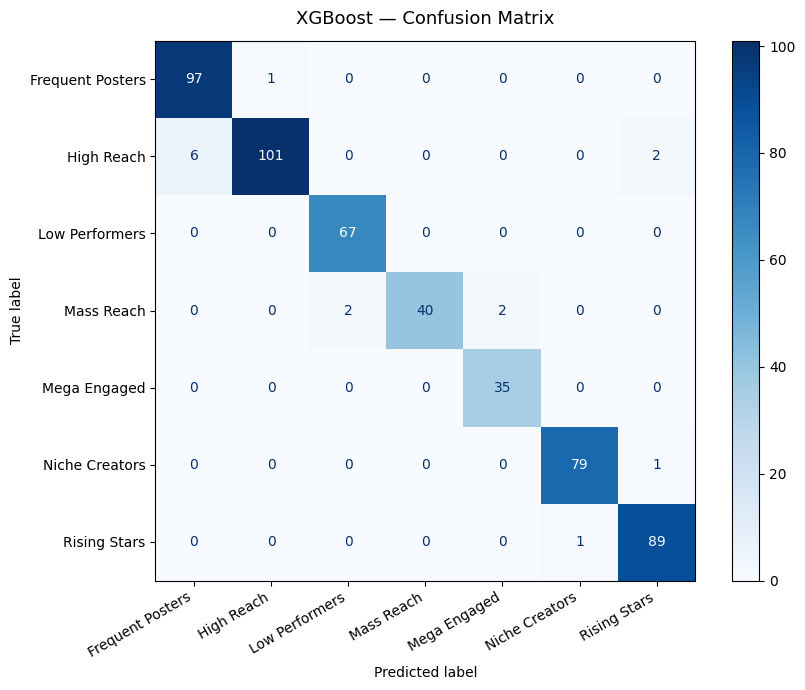

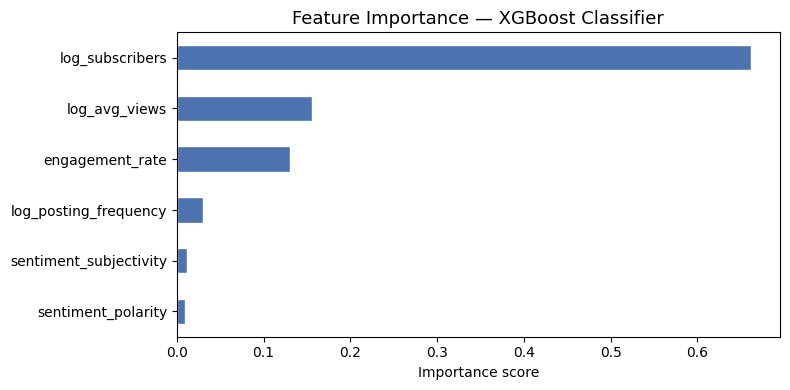


Cluster mismatch rate : 0.57%
(low = model agrees well with K-Means clusters)

STAGE 5B — CLASSIFICATION COMPLETE
New columns: predicted_cluster, cluster_confidence, cluster_mismatch
Shape: (2836, 30)
Saved → influencers_classified.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      ConfusionMatrixDisplay,
                                      roc_auc_score)
from xgboost                  import XGBClassifier

# ─────────────────────────────────
# 1. Prepare data
#    Only Micro/Macro/Mega have cluster labels
#    Nano and "Unknown" are excluded
# ─────────────────────────────────
df_clf = df_nlp[
    df_nlp["cluster_label"].notna() &
    (df_nlp["cluster_label"] != "Unknown")
].copy()

print(f"Samples for classification : {len(df_clf)}")
print("Class distribution:")
print(df_clf["cluster_label"].value_counts())

# Features
FEATURES = [
    "log_subscribers",
    "log_avg_views",
    "engagement_rate",
    "log_posting_frequency",
    "sentiment_polarity",        # from Stage 5A
    "sentiment_subjectivity"     # from Stage 5A
]

X = df_clf[FEATURES]
y_raw = df_clf["cluster_label"]

# Encode string labels → integers
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f"\nClasses: {le.classes_}")

# ─────────────────────────────────
# 2. Train / Test split  (stratified so every
#    class appears in both sets)
# ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f"\nTrain size : {len(X_train)}")
print(f"Test  size : {len(X_test)}")

# ─────────────────────────────────
# 3. XGBoost model
#    use_label_encoder=False and eval_metric
#    suppress the deprecation warning
# ─────────────────────────────────
xgb_clf = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 5,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    eval_metric       = "mlogloss",
    verbosity         = 0
)

xgb_clf.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    verbose               = False
)

# ─────────────────────────────────
# 4. Evaluation
# ─────────────────────────────────
y_pred      = xgb_clf.predict(X_test)
y_pred_prob = xgb_clf.predict_proba(X_test)

print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(
    y_test, y_pred,
    target_names = le.classes_
))

# Cross-validation (5-fold) — more robust than a single split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_clf, X, y, cv=cv, scoring="accuracy")
print(f"5-Fold CV Accuracy : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ROC-AUC (one-vs-rest for multiclass)
auc = roc_auc_score(y_test, y_pred_prob, multi_class="ovr", average="macro")
print(f"Macro ROC-AUC      : {auc:.3f}")

# ─────────────────────────────────
# 5. Confusion matrix
# ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = le.classes_
)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("XGBoost — Confusion Matrix", fontsize=13, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ─────────────────────────────────
# 6. Feature importance (built-in XGBoost)
# ─────────────────────────────────
importances = pd.Series(
    xgb_clf.feature_importances_,
    index = FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Feature Importance — XGBoost Classifier", fontsize=13)
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()


# ─────────────────────────────────
# 8. Add predictions back to main DataFrame
# ─────────────────────────────────
df_classified = df_nlp.copy()

# Predict on ALL rows that have cluster labels
mask = (
    df_classified["cluster_label"].notna() &
    (df_classified["cluster_label"] != "Unknown")
)

preds       = xgb_clf.predict(df_classified.loc[mask, FEATURES])
pred_probs  = xgb_clf.predict_proba(df_classified.loc[mask, FEATURES])

df_classified.loc[mask, "predicted_cluster"]    = le.inverse_transform(preds)
df_classified.loc[mask, "cluster_confidence"]   = pred_probs.max(axis=1).round(4)

# Flag mismatches — where K-Means and XGBoost disagree
df_classified["cluster_mismatch"] = (
    df_classified["cluster_label"] != df_classified["predicted_cluster"]
)

mismatch_rate = df_classified.loc[mask, "cluster_mismatch"].mean()
print(f"\nCluster mismatch rate : {mismatch_rate:.2%}")
print("(low = model agrees well with K-Means clusters)")

# ─────────────────────────────────
# 9. Save
# ─────────────────────────────────
print("\n" + "="*55)
print("STAGE 5B — CLASSIFICATION COMPLETE")
print("="*55)
print("New columns: predicted_cluster, cluster_confidence, cluster_mismatch")
print(f"Shape: {df_classified.shape}")

df_classified.to_csv("influencers_classified.csv", index=False)
print("Saved → influencers_classified.csv")

# Keep the encoder for Stage 6 (recommendation)
# le  → LabelEncoder
# xgb_clf → trained classifier

In [ ]:
# ============================================================
# STAGE 6 — ENHANCED BRAND RECOMMENDATION ENGINE
# Input : df_classified  (output of Stage 5B)
# Output: ranked shortlist for brand
#
# Signals used:
#   1. influencer_score  — from Stage 3 scoring
#   2. NLP cosine similarity — brand brief matched to descriptions
#   Combined final_score = weighted blend of both signals
# ============================================================

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import cosine_similarity

# ─────────────────────────────────────────────
# 1. Build a TF-IDF matrix over ALL descriptions
#    so we can compute cosine similarity between
#    a brand's brief and each channel
# ─────────────────────────────────────────────
print("Building description TF-IDF index...")

tfidf_rec   = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
desc_matrix = tfidf_rec.fit_transform(
    df_classified["clean_desc"].fillna("")
)

print(f"TF-IDF index shape: {desc_matrix.shape}")


# ─────────────────────────────────────────────
# 2. Budget → tier mapping
# ─────────────────────────────────────────────
def get_affordable_tiers(budget):
    if budget is None:
        return ["Micro", "Macro", "Mega"]
    elif budget < 500:
        return ["Micro"]
    elif budget < 5000:
        return ["Micro", "Macro"]
    else:
        return ["Micro", "Macro", "Mega"]


GOAL_CLUSTER_MAP = {
    "engagement": ["High Engagement", "Rising Stars", "Mega Engaged"],
    "reach":      ["High Reach",      "Mass Reach"],
    "niche":      ["Niche Creators"],
    "consistent": ["Frequent Posters"]
}


# ─────────────────────────────────────────────
# 3. Recommendation function
# ─────────────────────────────────────────────
def recommend_influencers(
    df,
    niche          = None,
    country        = None,
    budget         = None,
    goal           = None,
    brand_brief    = None,
    min_engagement = 0.0,
    top_n          = 10,
    w_score        = 0.60,   # weight for influencer_score
    w_nlp          = 0.40,   # weight for NLP similarity
    verbose        = True
):
    """
    Enhanced brand recommendation engine.

    Parameters
    ----------
    df             : DataFrame  (df_classified)
    niche          : str        e.g. "Gaming"
    country        : str        e.g. "IN"
    budget         : float      USD per video — maps to tier
    goal           : str        "engagement" / "reach" / "niche" / "consistent"
    brand_brief    : str        short text describing brand/campaign
                                e.g. "sustainable fitness gear for women"
    min_engagement : float      minimum engagement rate
    top_n          : int        how many results to return
    w_score        : float      weight for base influencer_score  (default 0.60)
    w_nlp          : float      weight for NLP cosine similarity  (default 0.40)
    verbose        : bool       print filter steps

    Returns
    -------
    DataFrame with ranked influencer shortlist
    """
    result = df.copy()
    result["_orig_idx"] = result.index

    # — Step 1: niche filter
    if niche:
        result = result[result["niche"].str.lower() == niche.lower()]
        if verbose: print(f"  After niche filter     : {len(result)}")

    # — Step 2: country filter
    if country:
        result = result[result["country"].str.upper() == country.upper()]
        if verbose: print(f"  After country filter   : {len(result)}")

    # — Step 3: budget → tier filter
    affordable = get_affordable_tiers(budget)
    result     = result[result["influencer_tier"].isin(affordable)]
    if verbose:
        print(f"  After budget filter    : {len(result)}")
        print(f"  Affordable tiers       : {affordable}")

    # — Step 4: goal → cluster filter
    if goal and goal.lower() in GOAL_CLUSTER_MAP:
        preferred = GOAL_CLUSTER_MAP[goal.lower()]
        result    = result[result["cluster_label"].isin(preferred)]
        if verbose:
            print(f"  After goal filter      : {len(result)}")
            print(f"  Preferred clusters     : {preferred}")

    # — Step 5: min engagement filter
    if min_engagement > 0:
        result = result[result["engagement_rate"] >= min_engagement]
        if verbose: print(f"  After engagement filter: {len(result)}")

    # — Step 6: bail early if empty
    if result.empty:
        print("\n  No influencers found. Try relaxing budget / country / goal.")
        return pd.DataFrame()

    # — Step 7: NLP cosine similarity
    if brand_brief and brand_brief.strip():
        brief_vec            = tfidf_rec.transform([brand_brief])
        sims                 = cosine_similarity(
            brief_vec,
            desc_matrix[result["_orig_idx"].values]
        ).flatten()
        result["nlp_similarity"] = sims
    else:
        result["nlp_similarity"] = 0.5   # neutral if no brief given

    # Normalise nlp_similarity to 0-1 within this filtered set
    sim_min = result["nlp_similarity"].min()
    sim_max = result["nlp_similarity"].max()
    if sim_max > sim_min:
        result["nlp_sim_norm"] = (
            (result["nlp_similarity"] - sim_min) / (sim_max - sim_min)
        )
    else:
        result["nlp_sim_norm"] = 0.5

    # — Step 8: combined final score
    #   influencer_score is already 0-1 (from Stage 3)
    #   nlp_sim_norm     is already 0-1 (normalised above)
    result["final_score"] = (
        w_score * result["influencer_score"].fillna(0) +
        w_nlp   * result["nlp_sim_norm"]
    ).round(4)

    # — Step 9: rank and return
    output_cols = [
        "channel_name",
        "niche",
        "country",
        "influencer_tier",
        "cluster_label",
        "subscribers",
        "engagement_rate",
        "avg_views_per_video",
        "posting_frequency",
        "nlp_similarity",
        "influencer_score",
        "final_score"
    ]

    top = result.nlargest(top_n, "final_score")[output_cols]
    top = top.reset_index(drop=True)
    top.index += 1

    return top


print("✅ recommend_influencers() ready!")


# ─────────────────────────────────────────────
# 4. Test all 5 use cases
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("USE CASE 1: Small Gaming Brand | Budget $300 | Goal: Engagement")
print("="*65)
r1 = recommend_influencers(
    df_classified,
    niche       = "Gaming",
    budget      = 300,
    goal        = "engagement",
    brand_brief = "indie gaming brand promoting competitive online games",
    top_n       = 5
)
print(r1.to_string() if not r1.empty else "No results")

print("\n" + "="*65)
print("USE CASE 2: Beauty Brand India | Budget $2000 | Goal: Niche")
print("="*65)
r2 = recommend_influencers(
    df_classified,
    niche       = "Beauty",
    country     = "IN",
    budget      = 2000,
    goal        = "niche",
    brand_brief = "natural skincare brand for Indian women",
    top_n       = 5
)
print(r2.to_string() if not r2.empty else "No results")

print("\n" + "="*65)
print("USE CASE 3: Big Tech Brand | Budget $50000 | Goal: Reach")
print("="*65)
r3 = recommend_influencers(
    df_classified,
    niche       = "Tech",
    budget      = 50000,
    goal        = "reach",
    brand_brief = "enterprise cloud software platform for developers",
    top_n       = 5
)
print(r3.to_string() if not r3.empty else "No results")

print("\n" + "="*65)
print("USE CASE 4: Fitness Brand | No Budget | Min Engagement 4.0")
print("="*65)
r4 = recommend_influencers(
    df_classified,
    niche          = "Fitness",
    min_engagement = 4.0,
    brand_brief    = "gym supplements and protein powder for athletes",
    top_n          = 5
)
print(r4.to_string() if not r4.empty else "No results")

print("\n" + "="*65)
print("USE CASE 5: Any Brand | Budget $1000 | Top 10 Overall")
print("="*65)
r5 = recommend_influencers(
    df_classified,
    budget      = 1000,
    goal        = "engagement",
    brand_brief = "eco-friendly lifestyle products",
    top_n       = 10
)
print(r5.to_string() if not r5.empty else "No results")


Building description TF-IDF index...
TF-IDF index shape: (2836, 300)
✅ recommend_influencers() ready!

USE CASE 1: Small Gaming Brand | Budget $300 | Goal: Engagement
  After niche filter     : 169
  After budget filter    : 35
  Affordable tiers       : ['Micro']
  After goal filter      : 22
  Preferred clusters     : ['High Engagement', 'Rising Stars', 'Mega Engaged']
             channel_name   niche  country influencer_tier cluster_label  subscribers  engagement_rate  avg_views_per_video  posting_frequency  nlp_similarity  influencer_score  final_score
1  HGH Horror Games House  Gaming       TR           Micro  Rising Stars        95000           3.3851         27095.453575             216.19        0.468948            0.5417       0.7250
2         Indie Games Hub  Gaming       ID           Micro  Rising Stars        97600           2.4234         10036.871944             558.22        0.393291            0.4979       0.6342
3  I Dream of Indie Games  Gaming       US           Mic